In [ ]:
import os
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN
import tensorflow as tf

REF_DIR = 'data/reference_test_images'
IMG_SIZE = (178, 178)

mtcnn = MTCNN(image_size=178, margin=40, post_process=False)
mustache_model = tf.keras.models.load_model('models/mustache_detector_3.keras')
epic_model     = tf.keras.models.load_model('models/epic_detector_pinter.keras')

def prepare(image_path):
    img = Image.open(image_path).convert('RGB')
    face = mtcnn(img)
    if face is not None:
        arr = face.permute(1, 2, 0).numpy().astype(np.uint8)
    else:
        arr = np.array(img.resize(IMG_SIZE))
    return np.expand_dims(arr, axis=0)

def score(thin_prob, center, steepness):
    thin_prob = max(float(thin_prob), 1e-15)
    x = np.log10(thin_prob)
    c = np.log10(center)
    return float(np.clip(1 / (1 + np.exp(steepness * (x - c))), 0, 1))

candidates = [
    (0.0151, 0.8),
    (0.05, 1.0),
    (0.10, 1.0),
    (0.15, 1.0),
    (0.20, 1.2),
]

files = [f for f in os.listdir(REF_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"{'Bild':<25}{'mustache_prob':<15}{'thin_prob':<12}" + ''.join(f'c{c}/s{s:<8}' for c, s in candidates))
for fname in files:
    arr = prepare(os.path.join(REF_DIR, fname))
    m_prob = float(mustache_model.predict(arr, verbose=0)[0][0])
    t_prob = float(epic_model.predict(arr, verbose=0)[0][0])
    scores = [score(t_prob, c, s) * 100 for c, s in candidates]
    print(f"{fname[:24]:<25}{m_prob:<15.3f}{t_prob:<12.4f}" + ''.join(f'{sc:<10.1f}' for sc in scores))

Bild                     mustache_prob  thin_prob   c0.0151/s0.8     c0.05/s1.0     c0.1/s1.0     c0.15/s1.0     c0.2/s1.2     
Skärmavbild 2026-06-22  0.714          0.0307      43.9      55.3      62.6      66.6      72.7      
16009.png                1.000          0.0007      74.8      86.7      89.8      91.3      95.1      
160048.png               1.000          0.0000      96.9      99.2      99.4      99.5      99.9      
160049.png               0.556          0.0471      40.2      50.6      58.1      62.3      68.0      
16008.png                1.000          0.0000      99.2      99.8      99.9      99.9      100.0     
Skärmavbild 2026-06-22  0.181          0.0011      71.6      84.2      87.8      89.6      93.9      
Skärmavbild 2026-06-22  1.000          0.0326      43.3      54.6      61.9      66.0      72.0      
160014.png               1.000          0.0001      85.4      93.8      95.4      96.1      98.2      
160015.png               1.000          0.0000  

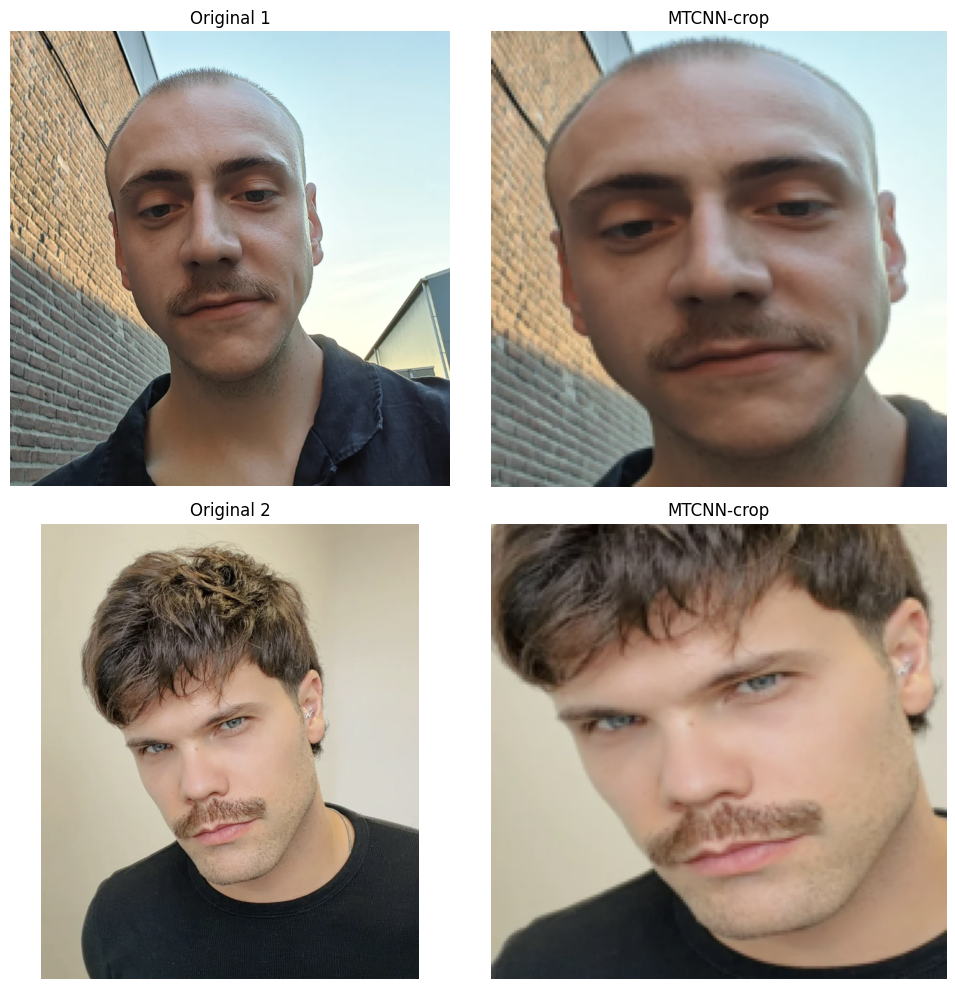

In [28]:
import matplotlib.pyplot as plt
from PIL import Image

two_problem_images = [
    'data/reference_test_images/16002.png',  # byt till rätt filnamn
    'data/reference_test_images/160017.png',
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i, path in enumerate(two_problem_images):
    original = Image.open(path).convert('RGB')
    face = mtcnn(original)
    cropped = Image.fromarray(face.permute(1, 2, 0).numpy().astype('uint8')) if face is not None else None

    axes[i][0].imshow(original)
    axes[i][0].set_title(f'Original {i+1}')
    axes[i][0].axis('off')

    if cropped:
        axes[i][1].imshow(cropped)
        axes[i][1].set_title('MTCNN-crop')
    else:
        axes[i][1].set_title('Inget ansikte hittat!')
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

In [16]:
for i, path in enumerate(two_problem_images):
    img = Image.open(path).convert('RGB')
    face = mtcnn(img)
    arr = face.permute(1, 2, 0).numpy().astype('uint8') if face is not None else np.array(img.resize((178,178)))
    arr = np.expand_dims(arr, axis=0)
    prob = float(mustache_model.predict(arr, verbose=0)[0][0])
    print(f'Bild {i+1}: mustache_prob = {prob:.3f}')

Bild 1: mustache_prob = 0.407
Bild 2: mustache_prob = 0.502
Bild 3: mustache_prob = 0.452


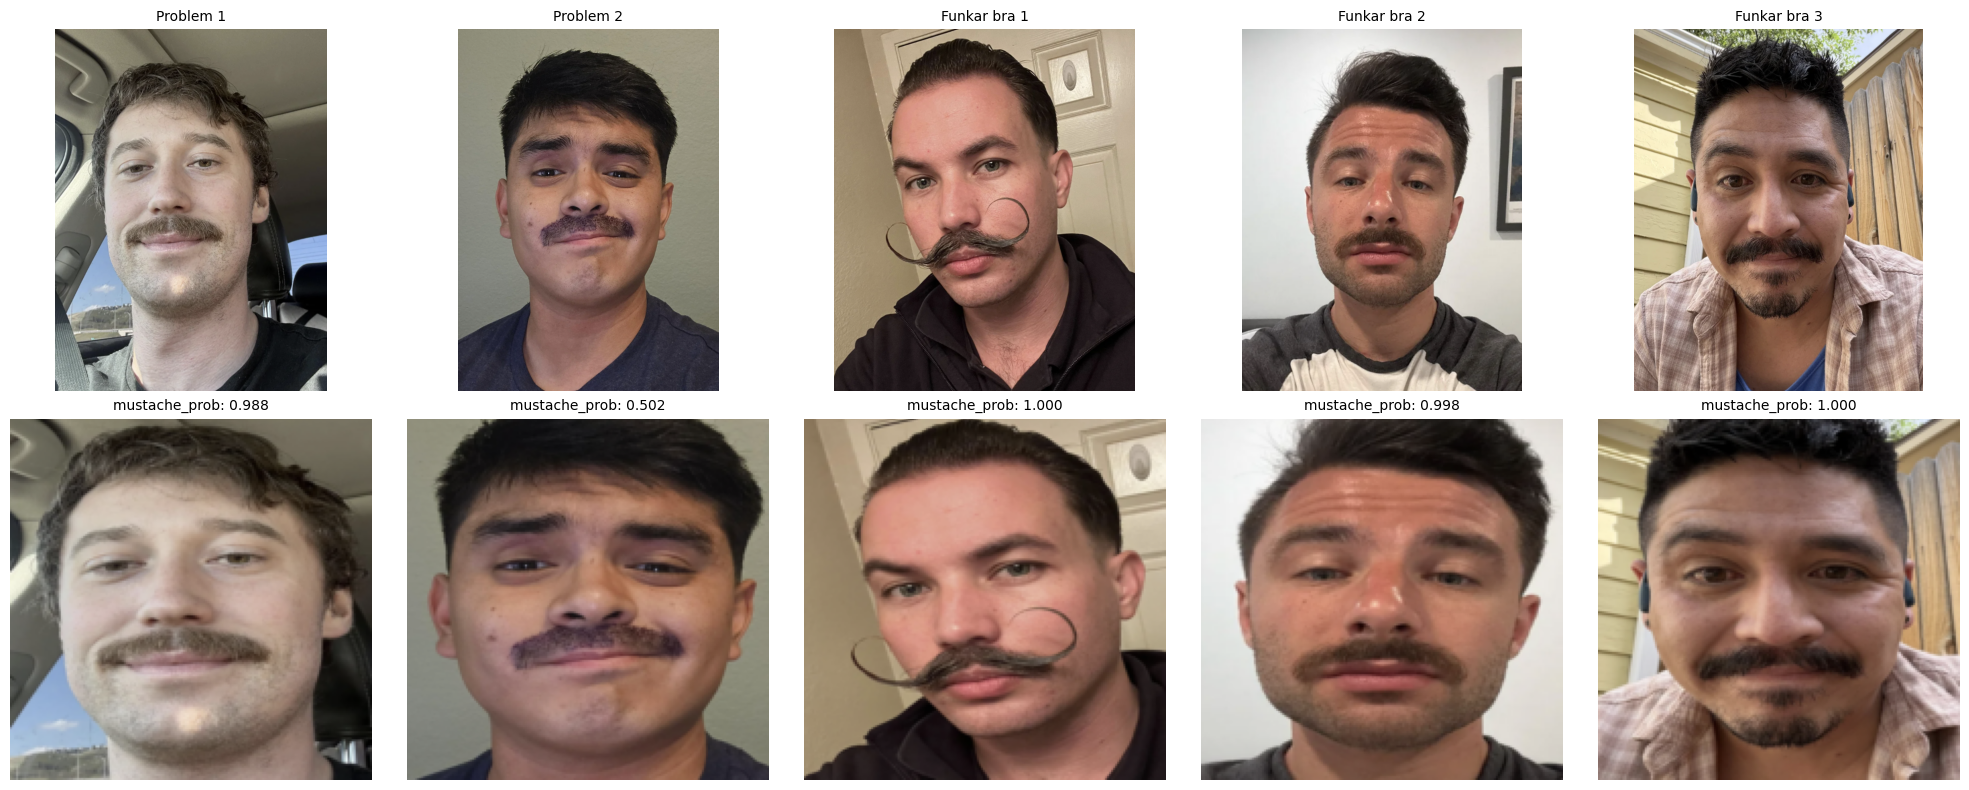

In [14]:
comparison_images = {
    'Problem 1': 'data/reference_test_images/134.png',
    'Problem 2': 'data/reference_test_images/131.png',
    'Funkar bra 1': 'data/reference_test_images/151.png',
    'Funkar bra 2': 'data/reference_test_images/120.png',
    'Funkar bra 3': 'data/reference_test_images/126.png',
}

fig, axes = plt.subplots(2, len(comparison_images), figsize=(4*len(comparison_images), 8))

for i, (label, path) in enumerate(comparison_images.items()):
    img = Image.open(path).convert('RGB')
    face = mtcnn(img)
    arr = face.permute(1, 2, 0).numpy().astype('uint8') if face is not None else np.array(img.resize((178, 178)))

    mustache_prob = float(mustache_model.predict(np.expand_dims(arr, axis=0), verbose=0)[0][0])

    axes[0][i].imshow(img)
    axes[0][i].set_title(label, fontsize=10)
    axes[0][i].axis('off')

    axes[1][i].imshow(arr)
    axes[1][i].set_title(f'mustache_prob: {mustache_prob:.3f}', fontsize=10)
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
from facenet_pytorch import MTCNN

mtcnn_detect = MTCNN(keep_all=False)  # bara för att se boxen, inte croppen

for label, path in comparison_images.items():
    img = Image.open(path).convert('RGB')
    boxes, probs = mtcnn_detect.detect(img)
    if boxes is not None:
        x1, y1, x2, y2 = boxes[0]
        w, h = x2 - x1, y2 - y1
        print(f'{label}: bredd={w:.0f} höjd={h:.0f}  ratio (w/h)={w/h:.2f}')
    else:
        print(f'{label}: inget ansikte hittat')

Problem 1: bredd=347 höjd=465  ratio (w/h)=0.75
Problem 2: bredd=333 höjd=434  ratio (w/h)=0.77
Funkar bra 1: bredd=494 höjd=653  ratio (w/h)=0.76
Funkar bra 2: bredd=222 höjd=303  ratio (w/h)=0.73
Funkar bra 3: bredd=393 höjd=524  ratio (w/h)=0.75


In [33]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf

REF_DIR = 'data/reference_test_images'
IMG_SIZE = (178, 178)

sigmoid_model = tf.keras.models.load_model('models/epic_detector_pinterest.keras')  # eller vilken som är din senaste
regression_model = tf.keras.models.load_model('models/epic_detector_regression.keras')

def thin_prob_to_epic_score(thin_prob, center=0.1, steepness=1.2):
    thin_prob = max(float(thin_prob), 1e-15)
    x = np.log10(thin_prob)
    c = np.log10(center)
    return float(np.clip(1 / (1 + np.exp(steepness * (x - c))), 0, 1))

files = [f for f in os.listdir(REF_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"{'Bild':<35}{'Sigmoid-score':<16}{'Regression-score':<18}")
for fname in files:
    path = os.path.join(REF_DIR, fname)
    img = Image.open(path).convert('RGB')

    face = mtcnn(img)
    arr = face.permute(1, 2, 0).numpy().astype(np.uint8) if face is not None else np.array(img.resize(IMG_SIZE))
    arr = np.expand_dims(arr, axis=0)

    thin_prob = float(sigmoid_model.predict(arr, verbose=0)[0][0])
    sigmoid_score = thin_prob_to_epic_score(thin_prob) * 100

    reg_raw = float(regression_model.predict(arr, verbose=0)[0][0])
    reg_score = np.clip(reg_raw, 0, 10) / 10 * 100

    print(f"{fname[:34]:<35}{sigmoid_score:<16.1f}{reg_score:<18.1f}")

Bild                               Sigmoid-score   Regression-score  
Skärmavbild 2026-06-22 kl. 20.37. 64.9            67.6              
16009.png                          93.2            93.3              
160048.png                         99.8            78.2              
160049.png                         59.7            62.6              
16008.png                          100.0           99.6              
Skärmavbild 2026-06-22 kl. 20.39. 91.5            85.7              
Skärmavbild 2026-06-22 kl. 20.39. 64.2            54.3              
160014.png                         97.4            90.3              
160015.png                         99.0            89.1              
160017.png                         28.8            53.5              
160012.png                         100.0           97.1              
160013.png                         99.0            91.4              
160011.png                         94.1            98.6              
160039.png          

In [34]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf

REF_DIR = 'data/reference_test_images'
IMG_SIZE = (178, 178)

epic_model = tf.keras.models.load_model('models/epic_detector.keras')  # din senaste sigmoid-modell

files = [f for f in os.listdir(REF_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Steg 1: räkna ut raw thin_prob EN gång per bild
raw_results = {}
for fname in files:
    path = os.path.join(REF_DIR, fname)
    img = Image.open(path).convert('RGB')
    face = mtcnn(img)
    arr = face.permute(1, 2, 0).numpy().astype(np.uint8) if face is not None else np.array(img.resize(IMG_SIZE))
    arr = np.expand_dims(arr, axis=0)
    thin_prob = float(epic_model.predict(arr, verbose=0)[0][0])
    raw_results[fname] = thin_prob

print('Klart med raw thin_prob för alla bilder!')

Klart med raw thin_prob för alla bilder!


In [35]:
def thin_prob_to_epic_score(thin_prob, center, steepness):
    thin_prob = max(float(thin_prob), 1e-15)
    x = np.log10(thin_prob)
    c = np.log10(center)
    return float(np.clip(1 / (1 + np.exp(steepness * (x - c))), 0, 1))

candidates = [
    (0.05, 1.0), (0.1, 1.0), (0.1, 1.2), (0.15, 1.0),
    (0.15, 1.2), (0.2, 1.2), (0.2, 1.4), (0.3, 1.4),
]

known_bad = ['sindy.jpg', '160017.png']  # ska vara LÅGA

print(f"{'Center/Steep':<15}" + "".join(f"{fname[:12]:<14}" for fname in known_bad) + "Medel (alla)")
for center, steepness in candidates:
    scores = {f: thin_prob_to_epic_score(p, center, steepness)*100 for f, p in raw_results.items()}
    bad_scores = [f"{scores.get(f, -1):.1f}" for f in known_bad]
    avg_all = np.mean(list(scores.values()))
    print(f"{center}/{steepness:<10}" + "".join(f"{s:<14}" for s in bad_scores) + f"{avg_all:.1f}")

Center/Steep   sindy.jpg     160017.png    Medel (alla)
0.05/1.0       22.5          25.3          58.1
0.1/1.0       28.1          31.5          63.2
0.1/1.2       24.5          28.2          63.7
0.15/1.0       31.8          35.4          66.1
0.15/1.2       28.6          32.7          66.9
0.2/1.2       31.8          36.0          69.2
0.2/1.4       29.1          33.9          69.8
0.3/1.4       34.4          39.6          73.3
